In [2]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


In [1]:
pip install notebook jupyter ipykernel

Note: you may need to restart the kernel to use updated packages.


In [3]:
df.head()

NameError: name 'df' is not defined

In [4]:
df = pd.read_csv('EDA.csv')

In [5]:
df.head()

,patient_id,cohort,age,gender,gender_M,BMI,diameter_cm,Total_length_cm,Total_volume_cm3,Total_SA_cm2,...,Asymmetry,Coefficient,smoker,pack_year,hypertension,diabetes,statin,ruptured,thrombus,inflam
0,AAA6,AAA_paper1,53,M,1,NaN,5.3,NaN,NaN,NaN,...,1.000,50.000,1.0,NaN,0.0,1.0,0.0,NaN,NaN,NaN
1,AAA4,AAA_paper1,55,M,1,NaN,8.5,NaN,NaN,NaN,...,1.000,40.000,1.0,0.0,NaN,0.0,1.0,1.0,NaN,NaN
2,AAA10,AAA_paper1,61,M,1,NaN,13.0,NaN,NaN,NaN,...,1.000,90.000,1.0,1.0,NaN,1.0,1.0,0.0,NaN,NaN
3,P4,Patient_1_15,65,M,1,27.76,5.6,9.3,136.9,14.8,...,0.370,0.612,0.0,NaN,1.0,NaN,0.0,NaN,NaN,NaN
4,P1,Patient_1_15,66,M,1,24.91,5.6,13.2,176.7,19.8,...,0.574,0.801,0.0,NaN,1.0,NaN,1.0,NaN,NaN,NaN


In [7]:
X = df.drop(columns=['ruptured'],axis=1)

In [8]:
X.head()

,patient_id,cohort,age,gender,gender_M,BMI,diameter_cm,Total_length_cm,Total_volume_cm3,Total_SA_cm2,...,Diameter_at_peak_wall_stress_cm,Asymmetry,Coefficient,smoker,pack_year,hypertension,diabetes,statin,thrombus,inflam
0,AAA6,AAA_paper1,53,M,1,NaN,5.3,NaN,NaN,NaN,...,NaN,1.000,50.000,1.0,NaN,0.0,1.0,0.0,NaN,NaN
1,AAA4,AAA_paper1,55,M,1,NaN,8.5,NaN,NaN,NaN,...,NaN,1.000,40.000,1.0,0.0,NaN,0.0,1.0,NaN,NaN
2,AAA10,AAA_paper1,61,M,1,NaN,13.0,NaN,NaN,NaN,...,NaN,1.000,90.000,1.0,1.0,NaN,1.0,1.0,NaN,NaN
3,P4,Patient_1_15,65,M,1,27.76,5.6,9.3,136.9,14.8,...,4.9,0.370,0.612,0.0,NaN,1.0,NaN,0.0,NaN,NaN
4,P1,Patient_1_15,66,M,1,24.91,5.6,13.2,176.7,19.8,...,3.8,0.574,0.801,0.0,NaN,1.0,NaN,1.0,NaN,NaN


In [9]:
print("Categories in 'patient_id' variable:     ",end=" " )
print(df['patient_id'].unique())

print("Categories in 'age' variable:  ",end=" ")
print(df['age'].unique())

print("Categories in'gende' variable:",end=" " )
print(df['gender'].unique())

print("Categories in 'BMI' variable:     ",end=" " )
print(df['BMI'].unique())

print("Categories in 'diameter_cm' variable:     ",end=" " )
print(df['diameter_cm'].unique())

Categories in 'patient_id' variable:      ['AAA6' 'AAA4' 'AAA10' 'P4' 'P1' 'P11' 'P7' 'P6' 'P3' 'P8' 'AAA7' 'AAA11'
 'P14' 'P15' 'AAA3' 'AAA5' 'AAA9' 'AAA2' 'AAA1' 'AAA8' 'P9' 'P13' 'P2'
 'P5' 'P12' 'P10']
Categories in 'age' variable:   [53 55 61 65 66 67 68 70 72 73 74 75 76 77 78 81 87]
Categories in'gende' variable: ['M' 'F']
Categories in 'BMI' variable:      [  nan 27.76 24.91 25.4  30.12 25.93 25.51 25.26 25.39 28.41 21.78 24.97
 28.67 31.01 23.62]
Categories in 'diameter_cm' variable:      [ 5.3  8.5 13.   5.6  6.5  5.7  6.   5.5  7.9  6.3  6.6  7.4  5.8  7.
  6.2  6.1  5.9  6.8  9. ]


In [10]:
y = df['ruptured']

In [11]:
y

0     NaN
1     1.0
2     0.0
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    0.0
11    0.0
12    NaN
13    NaN
14    0.0
15    NaN
16    0.0
17    0.0
18    0.0
19    NaN
20    NaN
21    NaN
22    NaN
23    NaN
24    NaN
25    NaN
Name: ruptured, dtype: float64

In [12]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [13]:

X = preprocessor.fit_transform(X)

c:\Users\kamle\anaconda3\envs\mlproject\lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\kamle\anaconda3\envs\mlproject\lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\kamle\anaconda3\envs\mlproject\lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [14]:
X.shape


(26, 69)

In [15]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((20, 69), (6, 69))

In [16]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [18]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


AttributeError: 'numpy.ndarray' object has no attribute 'dropna'

In [20]:
# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 2. Evaluation function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# 3. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Imputer + Scaler pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # NaN → mean
    ("scaler", StandardScaler())                  # scale features
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

# 5. Define models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

# 6. Loop through models
for name, model in models.items():
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluation
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    # Print results
    print(name)
    model_list.append(name)

    print("Model performance for Training set")
    print("- Root Mean Squared Error: {:.4f}".format(train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(train_mae))
    print("- R2 Score: {:.4f}".format(train_r2))
    print("----------------------------------")

    print("Model performance for Test set")
    print("- Root Mean Squared Error: {:.4f}".format(test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(test_mae))
    print("- R2 Score: {:.4f}".format(test_r2))
    r2_list.append(test_r2)

    print("="*35)
    print("\n")

# 7. Compare R² scores
results_df = pd.DataFrame({"Model": model_list, "Test R2": r2_list})
print(results_df.sort_values(by="Test R2", ascending=False))


c:\Users\kamle\anaconda3\envs\mlproject\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: [67 68]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\kamle\anaconda3\envs\mlproject\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: [67 68]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


ValueError: Input y contains NaN.

In [21]:
print(y.isnull().sum())

18


In [22]:
print(y.name)

ruptured


In [23]:
df =df.dropna(subset=['ruptured'])

In [24]:
print(y.isnull().sum())

18


In [25]:
df =df.dropna(subset=['ruptured'])

In [26]:
print(y.isnull().sum())

18


In [27]:
df =df.dropna(subset=['ruptured'])

x=df.drop(columns=['ruptured'],axis=1)
y = df['ruptured']
print(y.isnull().sum())

0


In [30]:
print(X.shape)
print(y.shape)

print(y.value_counts())

(26, 69)
(8,)
ruptured
0.0    7
1.0    1
Name: count, dtype: int64


In [31]:
print(y.isnull().sum())

0


In [32]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

ValueError: Input y contains NaN.

In [33]:
print(df.shape)

X = df.drop(columns=['ruptured'], axis=1)
y = df['ruptured']

print(X.shape)
print(y.shape)

(8, 25)
(8, 24)
(8,)


In [34]:
print(len(X))
print(len(y))

8
8


In [35]:
print(df.shape)
print(X.shape)
print(y.shape)
print(len(X), len(y))

(8, 25)
(8, 24)
(8,)
8 8


In [36]:
print(df.shape)
print(df['ruptured'].value_counts(dropna=False))

(8, 25)
ruptured
0.0    7
1.0    1
Name: count, dtype: int64


In [37]:
df_original = pd.read_csv("EDA.csv")
print(df_original.shape)
print(df_original['ruptured'].isnull().sum())

(26, 25)
18


In [39]:
print(df_original['diameter_cm'].isnull().sum())
print(df_original['diameter_cm'].describe())

0
count    26.000000
mean      6.700000
std       1.647786
min       5.300000
25%       5.700000
50%       6.150000
75%       6.950000
max      13.000000
Name: diameter_cm, dtype: float64


In [40]:
X = df_original.drop(columns=['diameter_cm'])
y = df_original['diameter_cm']

In [41]:
print(X.shape)
print(y.shape)

(26, 24)
(26,)


In [42]:
X = df_original.drop(columns=['diameter_cm', 'ruptured'])
y = df_original['diameter_cm']

In [43]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

ValueError: Input y contains NaN.

In [44]:
X = df_original.drop(columns=['diameter_cm', 'ruptured'])
y = df_original['diameter_cm']

print(y.isnull().sum())
print(X.shape)
print(y.shape)

0
(26, 23)
(26,)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
print(y_train.isnull().sum())
print(y_test.isnull().sum())

0
0


In [47]:
print(y.name)

diameter_cm


In [48]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

ValueError: could not convert string to float: 'P15'

In [49]:
# Drop ID/cohort type columns
X = df.drop(['patient_id','cohort'], axis=1)

# Encode categorical columns (like gender, location)
X = pd.get_dummies(X, drop_first=True)


In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)


ValueError: Cannot use mean strategy with non-numeric data:
could not convert string to float: 'P15'

In [51]:
X = df.drop(['patient_id','cohort'], axis=1)


In [52]:
X = pd.get_dummies(X, drop_first=True)


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # NaN → mean
    ("scaler", StandardScaler())                  # scale features
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)


ValueError: Cannot use mean strategy with non-numeric data:
could not convert string to float: 'P15'

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Load dataset
df = pd.read_csv("EDA.csv")

# 2. Drop ID/cohort type columns (non-numeric identifiers)
df = df.drop(['patient_id','cohort'], axis=1)

# 3. Encode categorical columns (gender, location वगैरह)
df = pd.get_dummies(df, drop_first=True)

# 4. Split features and target
X = df.drop('ruptured', axis=1)
y = df['ruptured'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Pipeline for numeric features
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # NaN → mean
    ("scaler", StandardScaler())                  # scale features
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [55]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

ValueError: could not convert string to float: 'P15'

In [56]:
print(X.select_dtypes(include='object').columns.tolist())

[]


In [57]:
print(X.select_dtypes(include='object').columns.tolist())

[]


In [58]:
for col in X.columns:
    print(col, X[col].dtype)

age int64


AttributeError: 'DataFrame' object has no attribute 'dtype'

In [59]:
print(X.columns.tolist())

['age', 'gender_M', 'BMI', 'diameter_cm', 'Total_length_cm', 'Total_volume_cm3', 'Total_SA_cm2', 'Diam_length', 'ROD', 'Diameter_at_peak_wall_stress_cm', 'Asymmetry', 'Coefficient', 'smoker', 'pack_year', 'hypertension', 'diabetes', 'statin', 'thrombus', 'inflam', 'gender_M', 'Peak_wall_stress_MPa_0.362', 'Peak_wall_stress_MPa_0.37', 'Peak_wall_stress_MPa_0.382', 'Peak_wall_stress_MPa_0.387', 'Peak_wall_stress_MPa_0.402', 'Peak_wall_stress_MPa_0.409', 'Peak_wall_stress_MPa_0.421', 'Peak_wall_stress_MPa_0.452', 'Peak_wall_stress_MPa_0.461', 'Peak_wall_stress_MPa_0.475', 'Peak_wall_stress_MPa_0.499', 'Peak_wall_stress_MPa_0.552', 'Peak_wall_stress_MPa_0.905', 'Peak_wall_stress_MPa_Unknown', 'Location_peak_wall_stress_Left', 'Location_peak_wall_stress_Posterior', 'Location_peak_wall_stress_Posterior-right']


In [60]:
print(X.dtypes)

age                                            int64
gender_M                                       int64
BMI                                          float64
diameter_cm                                  float64
Total_length_cm                              float64
Total_volume_cm3                             float64
Total_SA_cm2                                 float64
Diam_length                                  float64
ROD                                          float64
Diameter_at_peak_wall_stress_cm              float64
Asymmetry                                    float64
Coefficient                                  float64
smoker                                       float64
pack_year                                    float64
hypertension                                 float64
diabetes                                     float64
statin                                       float64
thrombus                                     float64
inflam                                       f

In [61]:
for col in X.columns:
    if X[col].astype(str).str.contains("P15", na=False).any():
        print("Found in:", col)

AttributeError: 'DataFrame' object has no attribute 'str'

In [62]:
print(df[df.astype(str).apply(lambda x: x.str.contains('P15', na=False)).any()])

C:\Users\kamle\AppData\Local\Temp\ipykernel_57112\4245552902.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[df.astype(str).apply(lambda x: x.str.contains('P15', na=False)).any()])


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [63]:
print(X.columns[X.columns.duplicated()])

Index(['gender_M'], dtype='object')


In [64]:
print(X.columns[X.columns.duplicated()])
print(df.select_dtypes(include=['object']).columns)

Index(['gender_M'], dtype='object')
Index([], dtype='object')


In [65]:
X = X.loc[:, ~X.columns.duplicated()]

In [66]:
print(X.columns[X.columns.duplicated()])
print(df.select_dtypes(include=['object']).columns)

Index([], dtype='object')
Index([], dtype='object')


In [67]:
# X aur y ko dobara banao
X = X.loc[:, ~X.columns.duplicated()]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(y_train.shape)

(20, 36)
(20,)


In [68]:
print(X_train.dtypes.unique())
print(y_train.dtype)

[dtype('int64') dtype('float64') dtype('bool')]
float64


In [69]:
import numpy as np

print(np.isfinite(X_train).all().all())
print(np.isfinite(y_train).all())

False
True


In [70]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

BMI                                 8
Total_length_cm                     8
Total_volume_cm3                    8
Total_SA_cm2                        8
Diam_length                         8
ROD                                 8
Diameter_at_peak_wall_stress_cm     8
pack_year                           9
hypertension                        7
diabetes                           12
statin                              1
thrombus                           20
inflam                             20
dtype: int64


In [71]:
# Numerical columns
X = X.fillna(X.median(numeric_only=True))

In [72]:
print(X.isnull().sum().sum())

52


In [73]:
print(X.isnull().sum()[X.isnull().sum() > 0])

thrombus    26
inflam      26
dtype: int64


In [74]:
print(X.dtypes)

age                                            int64
gender_M                                       int64
BMI                                          float64
diameter_cm                                  float64
Total_length_cm                              float64
Total_volume_cm3                             float64
Total_SA_cm2                                 float64
Diam_length                                  float64
ROD                                          float64
Diameter_at_peak_wall_stress_cm              float64
Asymmetry                                    float64
Coefficient                                  float64
smoker                                       float64
pack_year                                    float64
hypertension                                 float64
diabetes                                     float64
statin                                       float64
thrombus                                     float64
inflam                                       f

In [75]:
# Bahut zyada missing columns hata do
X = X.drop(columns=['thrombus', 'inflam'], errors='ignore')

# Baaki missing values fill karo
X = X.fillna(0)

print(X.isnull().sum().sum())

0


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

import numpy as np
print(np.isfinite(X_train).all().all())

True


In [77]:
print(X.isnull().sum()[X.isnull().sum() > 0])

Series([], dtype: int64)


In [78]:
X = X.drop(columns=['thrombus', 'inflam'], errors='ignore')
X = X.fillna(0)

print(X.isnull().sum().sum())

0


In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(y_train.shape)

(20, 34)
(20,)


In [80]:
import numpy as np

print(np.isfinite(X_train).all().all())
print(np.isfinite(y_train).all())

True
True


In [81]:
print("X_train NaN =", X_train.isnull().sum().sum())
print("y_train NaN =", y_train.isnull().sum())

print("X_test NaN =", X_test.isnull().sum().sum())
print("y_test NaN =", y_test.isnull().sum())

X_train NaN = 0
y_train NaN = 0
X_test NaN = 0
y_test NaN = 0


In [82]:
import numpy as np

print("X_train finite =", np.isfinite(X_train).all().all())
print("X_test finite =", np.isfinite(X_test).all().all())

X_train finite = True
X_test finite = True


In [83]:
print(X_train.columns[~np.isfinite(X_train).all()])

Index([], dtype='object')


In [84]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Series([], dtype: int64)


In [85]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Series([], dtype: int64)


In [86]:
print(y_train.isnull().sum())
print(y_test.isnull().sum())

0
0


In [87]:
print(np.isfinite(y_train).all())
print(np.isfinite(y_test).all())

True
True


In [88]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(20, 34)
(6, 34)
(20,)
(6,)


In [89]:
print(X_train.dtypes.unique())

[dtype('int64') dtype('float64') dtype('bool')]


In [90]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.1835
- Mean Absolute Error: 0.1319
- R2 Score: 0.9315


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.9277
- Mean Absolute Error: 0.6641
- R2 Score: 0.7293
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 2.1615
- Mean Absolute Error: 1.5731
- R2 Score: -8.5077


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.0534
- Mean Absolute Error: 0.0410
- R2 Score: 0.9991
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3789
- Mean Absolute Error: 0.2650
- R2 Score: 0.7079


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 1.3103
- Mean Absolute Error: 0.8390
- R2 Score: 0.4599
----------------------

In [91]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.1835
- Mean Absolute Error: 0.1319
- R2 Score: 0.9315


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.9277
- Mean Absolute Error: 0.6641
- R2 Score: 0.7293
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 2.1615
- Mean Absolute Error: 1.5731
- R2 Score: -8.5077


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.0534
- Mean Absolute Error: 0.0410
- R2 Score: 0.9991
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3789
- Mean Absolute Error: 0.2650
- R2 Score: 0.7079


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 1.3103
- Mean Absolute Error: 0.8390
- R2 Score: 0.4599
----------------------

In [92]:
results = pd.DataFrame({
    "Model": model_list,
    "R2 Score": r2_list
})

results.sort_values("R2 Score", ascending=False)

,Model,R2 Score
0,Linear Regression,0.931460
6,XGBRegressor,0.826378
8,AdaBoost Regressor,0.813450
4,Decision Tree,0.749011
2,Ridge,0.707899
5,Random Forest Regressor,0.597045
7,CatBoosting Regressor,-0.214738
3,K-Neighbors Regressor,-0.702521
1,Lasso,-8.507744


In [93]:
import pickle

best_model = LinearRegression()
best_model.fit(X_train, y_train)

pickle.dump(best_model, open("model.pkl", "wb"))

In [94]:
best_model = LinearRegression()
best_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [95]:
pred = best_model.predict(X_test)

print("Actual:", y_test.iloc[0])
print("Predicted:", pred[0])

Actual: 5.7
Predicted: 5.641841664570164


In [96]:
from sklearn.metrics import r2_score

print(r2_score(y_test, pred))

0.931460428036616


In [97]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model Saved Successfully")

Model Saved Successfully


In [98]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 93.15


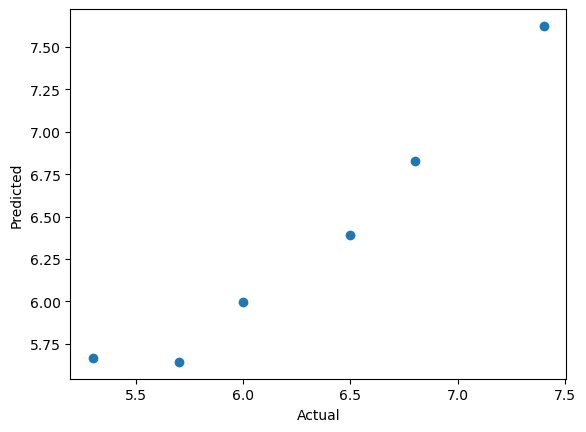

In [99]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

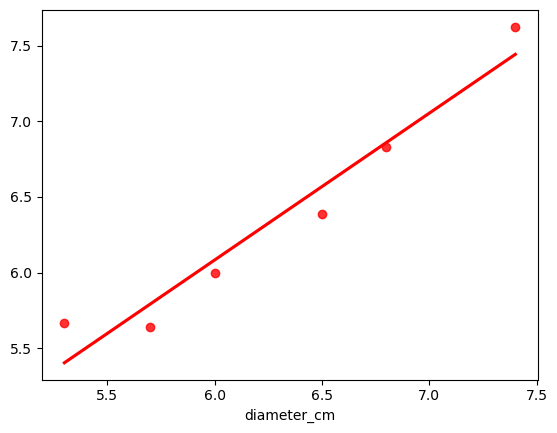

In [100]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [101]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
8,5.7,5.641842,0.058158
16,7.4,7.624761,-0.224761
0,5.3,5.667866,-0.367866
24,6.8,6.827884,-0.027884
11,6.5,6.390155,0.109845
9,6.0,5.997077,0.002923


In [102]:
best_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
for i in range(5):
    model = RandomForestRegressor()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    print(f"Run {i+1} R2 =", r2_score(y_test, pred))

Run 1 R2 = 0.7968214810627464
Run 2 R2 = 0.368611079706048
Run 3 R2 = 0.19299084228377728
Run 4 R2 = 0.5738446579988703
Run 5 R2 = 0.6433469756924814


In [104]:
RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [105]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print(scores)
print("Average R2 =", scores.mean())

[0.86507738 0.99774532 0.96327268 0.97620368 0.96642406]
Average R2 = 0.9537446245685726


In [106]:
import os

print(os.path.exists("model.pkl"))

True
